# A first look at a neural network

The book's opening example, run end to end in about twenty lines. The point is not the accuracy — it is that every line of it will be taken apart in the notebooks that follow.

**Runs on:** CPU — about 1 minute &nbsp;·&nbsp; **Slides:** [Chapter 2 — The Mathematical Building Blocks of Neural Networks](../../../course-web-slides/ch02/index.html) &nbsp;·&nbsp; **Section:** 01 — A first look at a neural network

---

## The data

In [1]:
import keras
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(train_images.shape, train_images.dtype)
print(train_labels[:10])
print(test_images.shape)

2026-08-31 17:10:19.399580: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


(60000, 28, 28) uint8
[5 0 4 1 9 2 1 3 1 4]
(10000, 28, 28)


Expected output:

```
(60000, 28, 28) uint8
[5 0 4 1 9 2 1 3 1 4]
(10000, 28, 28)
```

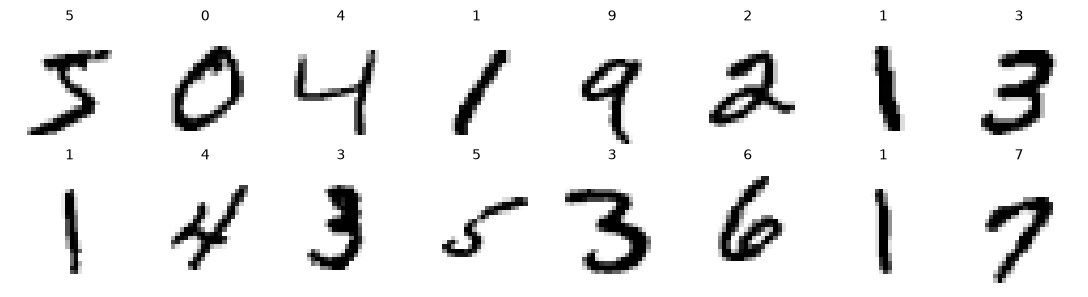

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for ax, img, lab in zip(axes.ravel(), train_images, train_labels):
    ax.imshow(img, cmap="gray_r")
    ax.set_title(int(lab), fontsize=10)
    ax.axis("off")
plt.tight_layout(); plt.show()

## The model: two dense layers

Two `Dense` layers. The first re-represents the 784 pixels as 512 numbers; the second turns those into ten probabilities. Chapter 1 called this a search for a useful representation, and this is the smallest honest instance of it.

In [3]:
from keras import layers

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

W0000 00:00:1788171023.781798  916142 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Preparing the data

Two changes, both required. Flatten each 28×28 image into a 784-vector, and scale the `uint8` range [0, 255] into floats in [0, 1].

In [4]:
train_x = train_images.reshape((60000, 28 * 28)).astype("float32") / 255
test_x = test_images.reshape((10000, 28 * 28)).astype("float32") / 255

print(train_x.shape, train_x.dtype, train_x.min(), train_x.max())

(60000, 784) float32 0.0 1.0


Expected output:

```
(60000, 784) float32 0.0 1.0
```

## Training

In [5]:
history = model.fit(train_x, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9226 - loss: 0.2678
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9689 - loss: 0.1074
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9790 - loss: 0.0699
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9842 - loss: 0.0513
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9887 - loss: 0.0375


Expected output:

```
Epoch 1/5
469/469 - 2s - loss: 0.2xxx - accuracy: 0.92xx
...
Epoch 5/5
469/469 - 2s - loss: 0.0xxx - accuracy: 0.98xx
```

## Predicting, and evaluating

In [6]:
predictions = model.predict(test_x[:10], verbose=0)

print("first test digit, probability per class:")
for i, p in enumerate(predictions[0]):
    print(f"  {i}: {p:.4f}")
print("argmax:", predictions[0].argmax(), " label:", test_labels[0])

first test digit, probability per class:
  0: 0.0000
  1: 0.0000
  2: 0.0001
  3: 0.0007
  4: 0.0000
  5: 0.0000
  6: 0.0000
  7: 0.9992
  8: 0.0000
  9: 0.0000
argmax: 7  label: 7


In [7]:
test_loss, test_acc = model.evaluate(test_x, test_labels, verbose=0)
print(f"test accuracy: {test_acc:.4f}")
print(f"train accuracy at the last epoch: {history.history['accuracy'][-1]:.4f}")

test accuracy: 0.9798
train accuracy at the last epoch: 0.9887


Expected output:

```
test accuracy: 0.97xx
train accuracy at the last epoch: 0.98xx
```

> **Note** — Test accuracy is **lower** than training accuracy. That gap has a name — overfitting — and chapter 5 is entirely about it. Notice it here so that it is not a surprise there.

## Looking at what it got wrong

A number on its own tells you very little. The mistakes tell you a great deal, and they cost nothing to look at.

202 wrong out of 10000


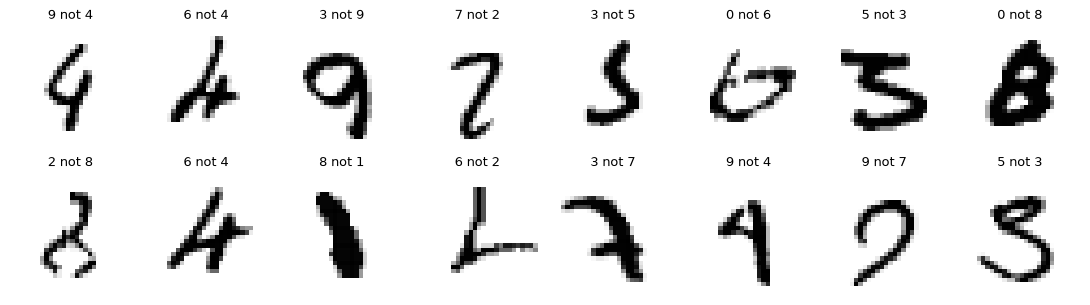

In [8]:
import numpy as np

probs = model.predict(test_x, verbose=0)
pred = probs.argmax(axis=1)
wrong = np.where(pred != test_labels)[0]
print(f"{len(wrong)} wrong out of {len(test_labels)}")

fig, axes = plt.subplots(2, 8, figsize=(11, 3.2))
for ax, i in zip(axes.ravel(), wrong[:16]):
    ax.imshow(test_images[i], cmap="gray_r")
    ax.set_title(f"{pred[i]} not {test_labels[i]}", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

Most of them are digits you would hesitate over yourself. A few are not — and those are the ones worth understanding.

---

## What to take away

- A working classifier is about twenty lines: data, two layers, compile, fit.
- Preprocessing is not optional — reshape and scale, every time.
- **Test accuracy below training accuracy is overfitting**, visible from the very first example.
- Always look at the errors. The number tells you how much; the errors tell you what.